In [68]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuel/Documents/belugas/beluga-call-pipeline
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import pandas as pd
from pathlib import Path

dir = "../final_results/resnet/"

# Loop through all folds and collect DataFrames
all_predictions = []
for fold_num in range(5):
    fold_path = Path(dir) / f"fold_{fold_num}" / "test_predictions.csv"
    fold_df = pd.read_csv(fold_path)
    all_predictions.append(fold_df)

# Merge all predictions into one DataFrame
test_predictions_df = pd.concat(all_predictions, ignore_index=True)
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold
0,BSM_20170724_09480300.pt,BSM,0.0,0.0,2.748227e-11,0.0,0.0,3.464269e-12,0.0,0.0,4.177938e-10,0.0,0.0,2.562697e-09,0
1,BSM_20170724_11080300.pt,BSM,0.0,0.0,2.186668e-08,0.0,0.0,1.530843e-06,0.0,0.0,3.228451e-08,0.0,0.0,5.211010e-07,0
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,8.270850e-12,0.0,0.0,2.804290e-12,0.0,0.0,7.431842e-11,0.0,0.0,4.469527e-10,0
3,BSM_20170724_12400200.pt,BSM,0.0,0.0,9.203779e-11,0.0,0.0,1.637473e-12,0.0,0.0,1.852635e-12,0.0,0.0,8.332861e-11,0
4,BSM_20170724_12400300.pt,BSM,0.0,0.0,1.215461e-12,0.0,0.0,6.456824e-14,0.0,0.0,4.644192e-12,0.0,0.0,4.262395e-11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11603,RDL_20200901_19125986.pt,RDL,0.0,0.0,1.882238e-15,0.0,0.0,2.117531e-17,0.0,0.0,3.708723e-16,0.0,0.0,3.814236e-17,4
11604,RDL_20200906_14553296.pt,RDL,0.0,0.0,1.059103e-15,0.0,0.0,1.530743e-17,0.0,0.0,1.470347e-14,0.0,0.0,2.229635e-15,4
11605,RDL_20200906_14555838.pt,RDL,0.0,0.0,5.848732e-13,0.0,0.0,4.505641e-13,0.0,0.0,3.944376e-13,0.0,0.0,9.961523e-13,4
11606,RDL_20200906_14555938.pt,RDL,0.0,0.0,4.840709e-14,0.0,0.0,1.333679e-15,0.0,0.0,3.634287e-15,0.0,0.0,1.684795e-16,4


In [70]:
import pandas as pd
labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")
labels_df["ClipFilenamePt"] = labels_df["clip_filename"].str.replace(".wav", ".pt", regex=False)

merged_df = test_predictions_df.merge(
    labels_df[["ClipFilenamePt", "Boat", "HydrophoneSensitivity"]],
    how="left",
    left_on="Filename",
    right_on="ClipFilenamePt"
)
test_predictions_df = merged_df.drop(columns=["ClipFilenamePt"])


In [71]:
test_predictions_df.head(2)

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity
0,BSM_20170724_09480300.pt,BSM,0.0,0.0,2.748227e-11,0.0,0.0,3.464269e-12,0.0,0.0,4.177938e-10,0.0,0.0,2.562697e-09,0,NaN,-172.7
1,BSM_20170724_11080300.pt,BSM,0.0,0.0,2.186668e-08,0.0,0.0,1.530843e-06,0.0,0.0,3.228451e-08,0.0,0.0,5.211010e-07,0,NaN,-172.7


In [72]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# Configuration
# =============================================================================
call_types = ["ECHO", "BBPC", "HFPC", "Whistle"]


# =============================================================================
# Core Metrics Functions
# =============================================================================
def get_multilabel_metrics(df, call_types, subset_name="Overall", true_suffix="_true", pred_suffix="_pred"):
    """
    Get multilabel metrics and confusion matrices for a dataframe subset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    subset_name : str
        Name for this subset (e.g., "Overall", "KAM_2020", "boat_passage")
        
    Returns:
    --------
    dict
        Dictionary containing metrics, confusion matrices, and metadata
    """
    if len(df) == 0:
        return None
        
    y_true = df[[f"{c}{true_suffix}" for c in call_types]].astype(int).values
    y_pred = df[[f"{c}{pred_suffix}" for c in call_types]].astype(int).values
    
    # Get classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=call_types, 
        output_dict=True, 
        zero_division=0
    )
    
    # Get confusion matrices
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    
    return {
        'report': report,
        'mcm': mcm,
        'y_true': y_true,
        'y_pred': y_pred,
        'name': subset_name,
        'n_samples': len(df)
    }


def compute_metrics_by_grouping(df, call_types, group_by=None):
    """
    Compute metrics for overall data and by grouping variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    group_by : str or None
        Column name to group by (e.g., 'context', 'site', or None for overall only)
        
    Returns:
    --------
    tuple
        (metrics_overall, metrics_by_group) where metrics_by_group is a dict
    """
    # Overall metrics
    metrics_overall = get_multilabel_metrics(df, call_types, "Overall")
    
    # Group-specific metrics
    metrics_by_group = {}
    if group_by and group_by in df.columns:
        unique_groups = df[group_by].unique()
        for group in unique_groups:
            df_group = df[df[group_by] == group]
            if len(df_group) > 0:
                metrics_by_group[group] = get_multilabel_metrics(df_group, call_types, str(group))
    
    return metrics_overall, metrics_by_group


def create_summary_dataframe(metrics_overall, metrics_by_group, call_types, group_name="Group"):
    """
    Create a summary dataframe from computed metrics.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    call_types : list
        List of call type names
    group_name : str
        Name for the grouping column (e.g., "Context", "Site")
        
    Returns:
    --------
    pd.DataFrame
        Summary dataframe with metrics for all call types and groups
    """
    summary_data = []
    
    for call in call_types:
        # Overall
        if metrics_overall:
            summary_data.append({
                'Call Type': call,
                group_name: 'Overall',
                'Precision': metrics_overall['report'][call]['precision'],
                'Recall': metrics_overall['report'][call]['recall'],
                'F1-Score': metrics_overall['report'][call]['f1-score'],
                'Support': int(metrics_overall['report'][call]['support'])
            })
        
        # By group
        for group_key, metrics in metrics_by_group.items():
            if metrics:
                summary_data.append({
                    'Call Type': call,
                    group_name: group_key,
                    'Precision': metrics['report'][call]['precision'],
                    'Recall': metrics['report'][call]['recall'],
                    'F1-Score': metrics['report'][call]['f1-score'],
                    'Support': int(metrics['report'][call]['support'])
                })
    
    return pd.DataFrame(summary_data)


def create_average_metrics_dataframe(metrics_overall, metrics_by_group, group_name="Group"):
    """
    Create dataframe with averaged metrics across all call types.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    group_name : str
        Name for the grouping column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with macro/micro/samples averages
    """
    avg_metrics = []
    
    # Overall
    if metrics_overall:
        report = metrics_overall['report']
        avg_metrics.append({
            group_name: 'Overall',
            'Macro Avg Precision': report['macro avg']['precision'],
            'Macro Avg Recall': report['macro avg']['recall'],
            'Macro Avg F1': report['macro avg']['f1-score'],
            'Micro Avg F1': report['micro avg']['f1-score'],
            'Samples Avg F1': report['samples avg']['f1-score'],
            'n_samples': metrics_overall['n_samples']
        })
    
    # By group
    for group_key, metrics in metrics_by_group.items():
        if metrics:
            report = metrics['report']
            avg_metrics.append({
                group_name: group_key,
                'Macro Avg Precision': report['macro avg']['precision'],
                'Macro Avg Recall': report['macro avg']['recall'],
                'Macro Avg F1': report['macro avg']['f1-score'],
                'Micro Avg F1': report['micro avg']['f1-score'],
                'Samples Avg F1': report['samples avg']['f1-score'],
                'n_samples': metrics['n_samples']
            })
    
    return pd.DataFrame(avg_metrics)


def plot_metrics_comparison(summary_df, group_name="Group", exclude_overall=True, figsize=(14, 10)):
    """
    Create bar plots comparing metrics across call types and groups.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with metrics
    group_name : str
        Name of the grouping column
    exclude_overall : bool
        Whether to exclude 'Overall' from visualization
    figsize : tuple
        Figure size
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    # Filter data
    plot_df = summary_df.copy()
    if exclude_overall:
        plot_df = plot_df[plot_df[group_name] != 'Overall']
    
    if len(plot_df) == 0:
        print("No data to plot after filtering")
        return None
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Pivot data for plotting
        pivot_data = plot_df.pivot(index='Call Type', columns=group_name, values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(f'{metric} by Call Type and {group_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Call Type')
        ax.set_ylabel(metric)
        ax.legend(title=group_name, loc='best')
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-limit only for percentage metrics
        if metric in ['Precision', 'Recall', 'F1-Score']:
            ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    return fig


def print_classification_report(metrics_overall, call_types):
    """Print formatted classification report."""
    if metrics_overall:
        print(f"\n{'='*80}")
        print("OVERALL CLASSIFICATION REPORT")
        print(f"{'='*80}\n")
        print(classification_report(
            metrics_overall['y_true'], 
            metrics_overall['y_pred'], 
            target_names=call_types, 
            zero_division=0
        ))


def print_summary_table(summary_df, group_name="Group"):
    """Print formatted summary table."""
    print(f"\n\n{'='*80}")
    print(f"SUMMARY TABLE: All Call Types by {group_name}")
    print(f"{'='*80}\n")
    print(summary_df.to_string(index=False))


def print_average_metrics(avg_df, group_name="Group"):
    """Print formatted average metrics table."""
    print(f"\n\n{'='*80}")
    print(f"AVERAGE METRICS ACROSS ALL CALL TYPES BY {group_name}")
    print(f"{'='*80}\n")
    print(avg_df.to_string(index=False))

In [75]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity
0,BSM_20170724_09480300.pt,BSM,0.0,0.0,2.748227e-11,0.0,0.0,3.464269e-12,0.0,0.0,4.177938e-10,0.0,0.0,2.562697e-09,0,NaN,-172.7
1,BSM_20170724_11080300.pt,BSM,0.0,0.0,2.186668e-08,0.0,0.0,1.530843e-06,0.0,0.0,3.228451e-08,0.0,0.0,5.211010e-07,0,NaN,-172.7
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,8.270850e-12,0.0,0.0,2.804290e-12,0.0,0.0,7.431842e-11,0.0,0.0,4.469527e-10,0,NaN,-172.7
3,BSM_20170724_12400200.pt,BSM,0.0,0.0,9.203779e-11,0.0,0.0,1.637473e-12,0.0,0.0,1.852635e-12,0.0,0.0,8.332861e-11,0,NaN,-172.7
4,BSM_20170724_12400300.pt,BSM,0.0,0.0,1.215461e-12,0.0,0.0,6.456824e-14,0.0,0.0,4.644192e-12,0.0,0.0,4.262395e-11,0,NaN,-172.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11603,RDL_20200901_19125986.pt,RDL,0.0,0.0,1.882238e-15,0.0,0.0,2.117531e-17,0.0,0.0,3.708723e-16,0.0,0.0,3.814236e-17,4,NaN,-176.5
11604,RDL_20200906_14553296.pt,RDL,0.0,0.0,1.059103e-15,0.0,0.0,1.530743e-17,0.0,0.0,1.470347e-14,0.0,0.0,2.229635e-15,4,NaN,-176.5
11605,RDL_20200906_14555838.pt,RDL,0.0,0.0,5.848732e-13,0.0,0.0,4.505641e-13,0.0,0.0,3.944376e-13,0.0,0.0,9.961523e-13,4,NaN,-176.5
11606,RDL_20200906_14555938.pt,RDL,0.0,0.0,4.840709e-14,0.0,0.0,1.333679e-15,0.0,0.0,3.634287e-15,0.0,0.0,1.684795e-16,4,NaN,-176.5


In [82]:
# =============================================================================
# ANALYSIS BY CONTEXT
# =============================================================================
print("="*80)
print("ANALYSIS BY CONTEXT")
print("="*80)

# Compute metrics
metrics_overall, metrics_by_context = compute_metrics_by_grouping(
    test_predictions_df, call_types, group_by='Boat'
)
# Print reports
print_classification_report(metrics_overall, call_types)


ANALYSIS BY CONTEXT

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.95      0.95      3562
        BBPC       0.85      0.78      0.81       743
        HFPC       0.88      0.87      0.87       633
     Whistle       0.89      0.87      0.88      1981

   micro avg       0.92      0.90      0.91      6919
   macro avg       0.89      0.87      0.88      6919
weighted avg       0.92      0.90      0.91      6919
 samples avg       0.34      0.33      0.33      6919



In [83]:
metrics_by_context

{0.0: {'report': {'ECHO': {'precision': 0.9488982653539616,
    'recall': 0.9431500465983225,
    'f1-score': 0.9460154241645244,
    'support': 2146.0},
   'BBPC': {'precision': 0.8727272727272727,
    'recall': 0.8,
    'f1-score': 0.8347826086956521,
    'support': 660.0},
   'HFPC': {'precision': 0.8762475049900199,
    'recall': 0.8815261044176707,
    'f1-score': 0.8788788788788788,
    'support': 498.0},
   'Whistle': {'precision': 0.9079572446555819,
    'recall': 0.8946752486834406,
    'f1-score': 0.9012673150604185,
    'support': 1709.0},
   'micro avg': {'precision': 0.9181393459272801,
    'recall': 0.9016556951924996,
    'f1-score': 0.9098228663446055,
    'support': 5013.0},
   'macro avg': {'precision': 0.9014575719317091,
    'recall': 0.8798378499248585,
    'f1-score': 0.8902360566998685,
    'support': 5013.0},
   'weighted avg': {'precision': 0.9176951657791783,
    'recall': 0.9016556951924996,
    'f1-score': 0.909446069243195,
    'support': 5013.0},
   'sampl



AVERAGE METRICS ACROSS ALL CALL TYPES BY Boat

   Boat  Macro Avg Precision  Macro Avg Recall  Macro Avg F1  Micro Avg F1  Samples Avg F1  n_samples
Overall             0.891836          0.865340      0.878159      0.908083        0.331459      11608
    0.0             0.901458          0.879838      0.890236      0.909823        0.838476       2939
    1.0             0.843492          0.770772      0.804830      0.911961        0.744508       1858


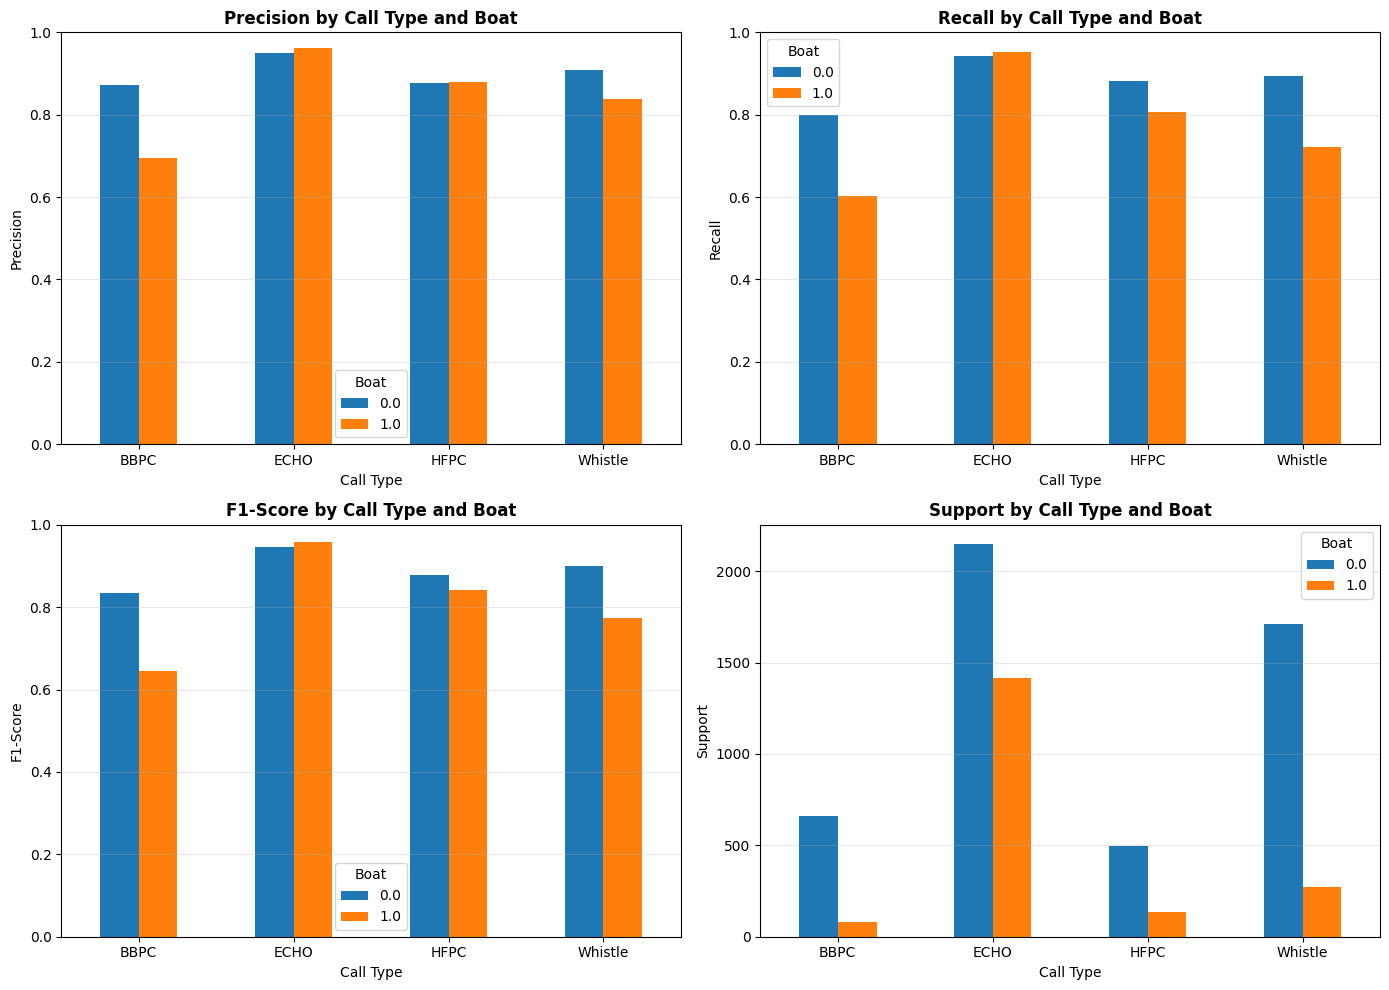

In [84]:




avg_by_context = create_average_metrics_dataframe(
    metrics_overall, metrics_by_context, group_name="Boat"
)
print_average_metrics(avg_by_context, "Boat")


# Create summary dataframes
summary_by_context = create_summary_dataframe(
    metrics_overall, metrics_by_context, call_types, group_name="Boat"
)

# Plot
fig_context = plot_metrics_comparison(
    summary_by_context, group_name="Boat", exclude_overall=True
)
plt.show()

## looking at the errors spectrograms

In [59]:
test_predictions_df["ECHO_correct"] = test_predictions_df["ECHO_pred"] == test_predictions_df["ECHO_true"]
test_predictions_df["BBPC_correct"] = test_predictions_df["BBPC_pred"] == test_predictions_df["BBPC_true"]
test_predictions_df["HFPC_correct"] = test_predictions_df["HFPC_pred"] == test_predictions_df["BBPC_true"]
test_predictions_df["Whistle_correct"] = test_predictions_df["Whistle_pred"] == test_predictions_df["BBPC_true"]

In [60]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,...,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct
0,BSM_20170724_09480300.pt,BSM,0.0,0.0,2.748227e-11,0.0,0.0,3.464269e-12,0.0,0.0,...,0.0,0.0,2.562697e-09,0,NaN,-172.7,True,True,True,True
1,BSM_20170724_11080300.pt,BSM,0.0,0.0,2.186668e-08,0.0,0.0,1.530843e-06,0.0,0.0,...,0.0,0.0,5.211010e-07,0,NaN,-172.7,True,True,True,True
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,8.270850e-12,0.0,0.0,2.804290e-12,0.0,0.0,...,0.0,0.0,4.469527e-10,0,NaN,-172.7,True,True,True,True
3,BSM_20170724_12400200.pt,BSM,0.0,0.0,9.203779e-11,0.0,0.0,1.637473e-12,0.0,0.0,...,0.0,0.0,8.332861e-11,0,NaN,-172.7,True,True,True,True
4,BSM_20170724_12400300.pt,BSM,0.0,0.0,1.215461e-12,0.0,0.0,6.456824e-14,0.0,0.0,...,0.0,0.0,4.262395e-11,0,NaN,-172.7,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11603,RDL_20200901_19125986.pt,RDL,0.0,0.0,1.882238e-15,0.0,0.0,2.117531e-17,0.0,0.0,...,0.0,0.0,3.814236e-17,4,NaN,-176.5,True,True,True,True
11604,RDL_20200906_14553296.pt,RDL,0.0,0.0,1.059103e-15,0.0,0.0,1.530743e-17,0.0,0.0,...,0.0,0.0,2.229635e-15,4,NaN,-176.5,True,True,True,True
11605,RDL_20200906_14555838.pt,RDL,0.0,0.0,5.848732e-13,0.0,0.0,4.505641e-13,0.0,0.0,...,0.0,0.0,9.961523e-13,4,NaN,-176.5,True,True,True,True
11606,RDL_20200906_14555938.pt,RDL,0.0,0.0,4.840709e-14,0.0,0.0,1.333679e-15,0.0,0.0,...,0.0,0.0,1.684795e-16,4,NaN,-176.5,True,True,True,True


In [61]:
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [65]:
test_predictions_df["Boat"].value_counts()

Boat
0.0    2939
1.0    1858
Name: count, dtype: int64

KAM_20200726_19240500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 0 vs pred 0


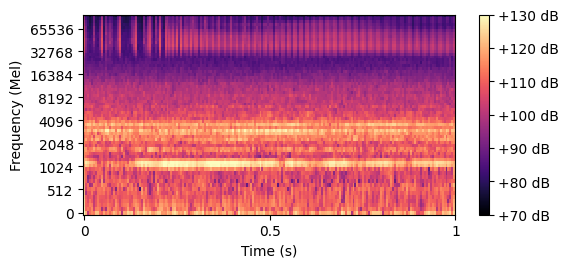

KAM_20200726_19211700.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 0 vs pred 0


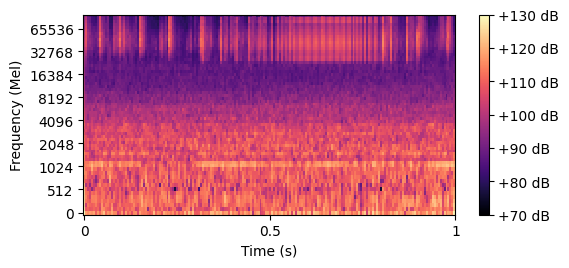

KAM_20200726_19583200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 0 vs pred 0


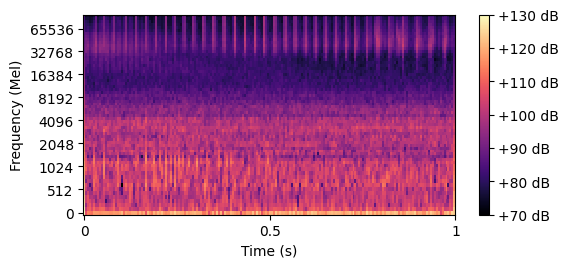

CAC_20210714_08371000.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 1


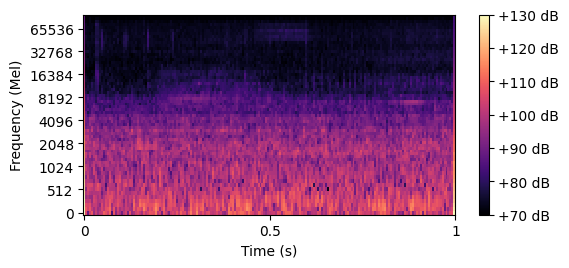

KAM_20200726_19241200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 0 vs pred 0


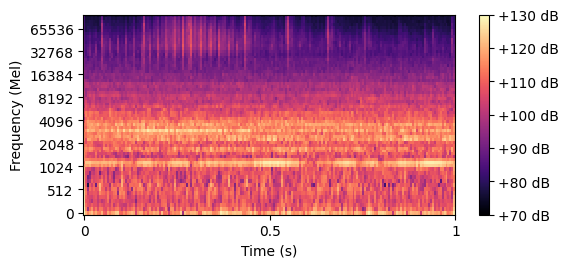

CAC_20210714_08395500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 1


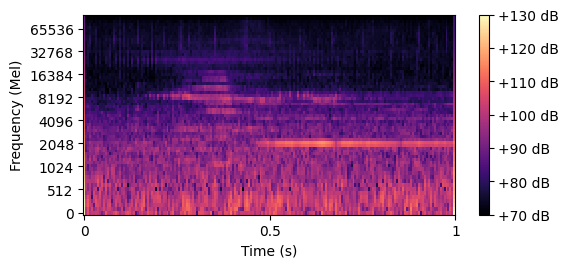

BSM_20170724_13410100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 0 vs pred 0


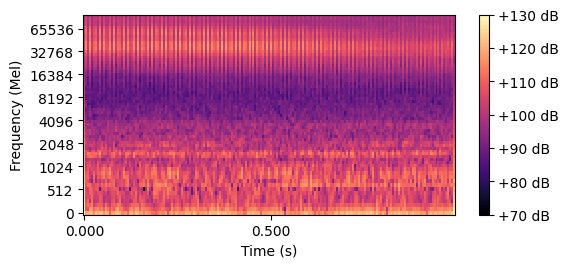

CAC_20210714_08382900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 1


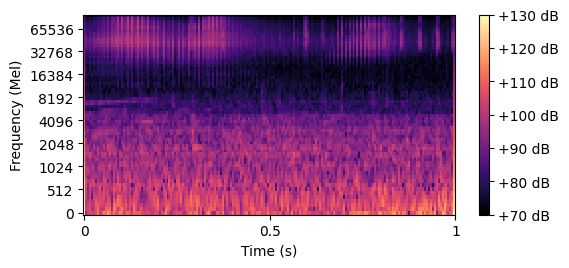

CAC_20210714_08330700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 1


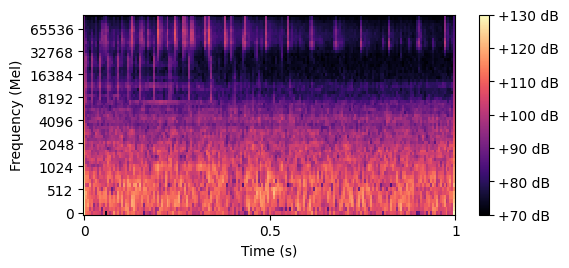

CAC_20210714_08401400.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 1   Whistle: true 1 vs pred 1


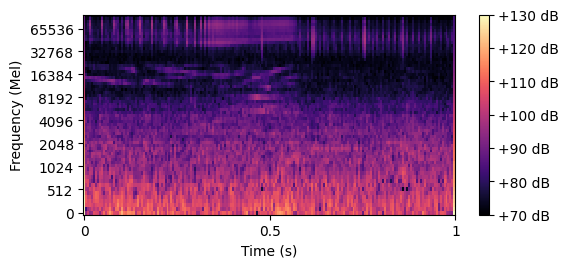

In [66]:

DATA_DIRECTORY = "../../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
boat_df = test_predictions_df[test_predictions_df["Boat"] == 1]
sample = boat_df[boat_df["BBPC_correct"] == False].sample(10)

for index, row in sample.iterrows():    
    wav_filename = row["Filename"].replace(".pt", ".wav")
    
    title = f"{wav_filename}\n"

    for label in ["ECHO", "HFPC", "BBPC", "Whistle"]:
        true_val = row[f"{label}_true"] if f"{label}_true" in row else row.get(label, None)
        pred_val = row[f"{label}_pred"] if f"{label}_pred" in row else None
        title += f"{label}: true {int(true_val)} vs pred {int(pred_val)}   "
    title = title.strip()
    print(title)
    # print("Boat:", row["Boat"])

    file_path = wavs_folder + wav_filename

    audio, sr, original_sr = spect_generator.load_audio(file_path)


    power_spect = spect_generator.compute_mel_power_spect(audio)

    
    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    